## 0. SetupRun the cell below once to install dependencies. All libraries are standard scientific Python — no GPU required.

In [1]:
# Run once. If you're on Google Colab, all of these are pre-installed.
# !pip install -q numpy pandas matplotlib scipy scikit-learn seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix

# Make plots a bit nicer
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("colorblind")

np.random.seed(42)
print("Setup complete.")

Setup complete.


---## Part 1 — Understanding Multivariate Time-Series Sensor Data### What rail telematics actually looks likeA rolling-stock bogie carries multiple sensors. For this tutorial we focus on **accelerometer (vibration) data** — the workhorse signal for detecting wheel flats, bearing defects, and bogie instability.| Property | What it means | Typical value (rail bogie) ||---|---|---|| Sampling frequency | How many readings per second | 1–20 kHz for vibration || Multivariate | Multiple correlated channels | 3-axis IMU: X, Y, Z || Non-stationary | Statistics drift with speed, load, track | Yes — must normalise || Sparsely labelled | Fault events are rare | Use **unsupervised** methods |### About the data we'll useIn class, we use the **CWRU Bearing Dataset** (Case Western Reserve University) — the de-facto benchmark for predictive-maintenance research [Liu et al. 2008; cited by 1,000+ papers].> If you have the dataset locally, load it with `scipy.io.loadmat('48k_Drive_End_OR007@6_0_130.mat')` and skip the synthetic generator below.For self-paced learners and reproducibility, this notebook ships with a **synthetic vibration generator** that mimics the key statistical properties of healthy bearings and outer-race faults. Everything you learn here transfers directly to the real CWRU data — only the file-loading line changes.

In [2]:
# ──────────────────────────────────────────────────────────────────────
# Synthetic vibration generator — mimics CWRU bearing data characteristics
# ──────────────────────────────────────────────────────────────────────
# Healthy bearing: low-amplitude broadband noise (Gaussian)
# Faulty bearing: same baseline + impulsive spikes at the ball-pass frequency
# This is how outer-race faults actually look in vibration spectra.

FS = 48_000          # sampling frequency in Hz (matches CWRU drive-end data)
DURATION_S = 10      # 10 seconds of signal
N_SAMPLES = FS * DURATION_S

def healthy_bearing(n=N_SAMPLES, noise_level=0.05):
    """Low-amplitude white noise — like a well-greased bearing."""
    return np.random.randn(n) * noise_level

def faulty_bearing(n=N_SAMPLES, noise_level=0.05, fault_freq_hz=150, impact_amp=0.6):
    """Healthy baseline + periodic impulses at ball-pass frequency."""
    signal = np.random.randn(n) * noise_level
    impact_period = int(FS / fault_freq_hz)  # samples between impacts
    # Decaying impulse response — what a defect actually produces
    impulse_response_len = 200
    decay = np.exp(-np.linspace(0, 4, impulse_response_len))
    impulse = np.sin(2 * np.pi * 2000 * np.arange(impulse_response_len) / FS) * decay
    for start in range(0, n - impulse_response_len, impact_period):
        signal[start:start + impulse_response_len] += impulse * impact_amp
    return signal

signal_healthy = healthy_bearing()
signal_faulty  = faulty_bearing()

print(f"Healthy signal shape: {signal_healthy.shape}")
print(f"Faulty signal shape:  {signal_faulty.shape}")
print(f"Sampling: {FS:,} Hz | Duration: {DURATION_S}s")
print(f"Total samples per signal: {N_SAMPLES:,}")

Healthy signal shape: (480000,)
Faulty signal shape:  (480000,)
Sampling: 48,000 Hz | Duration: 10s
Total samples per signal: 480,000


### Visual inspection — your first business decision is whether the data looks reasonableAlways plot before modelling. The eye catches problems no metric can.

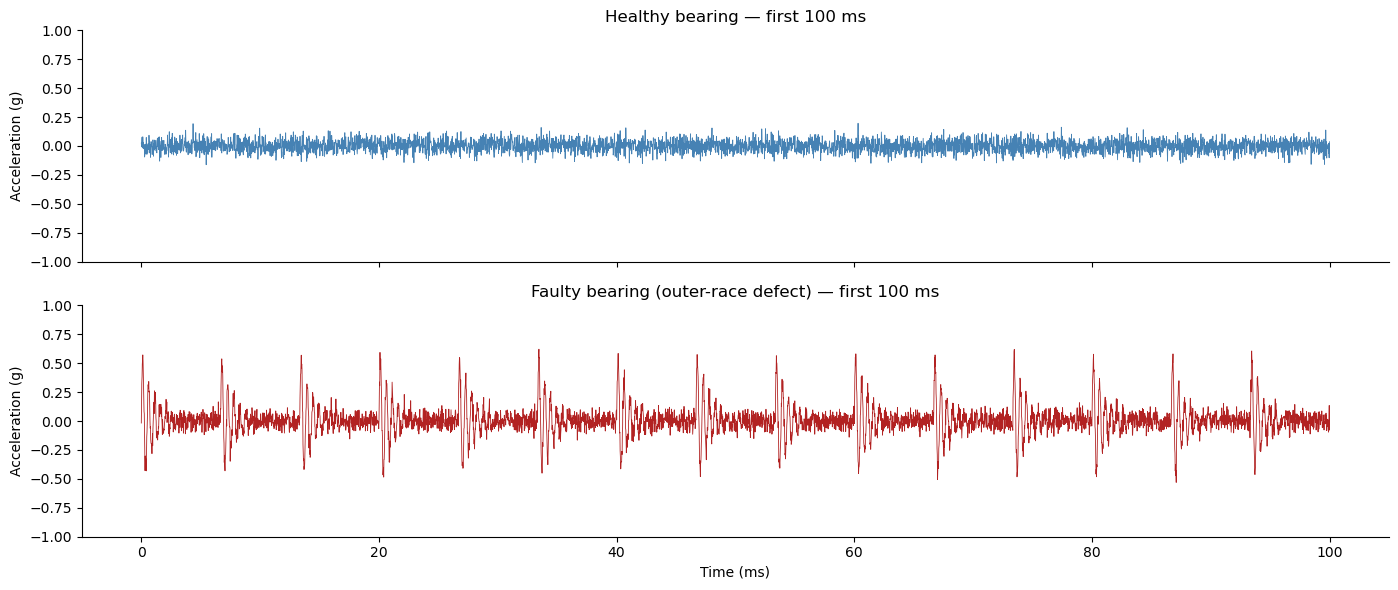

In [3]:
# Plot first 100 milliseconds of each signal
window_samples = int(0.1 * FS)  # 100 ms

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
t = np.arange(window_samples) / FS * 1000  # ms

axes[0].plot(t, signal_healthy[:window_samples], lw=0.6, color="steelblue")
axes[0].set_title("Healthy bearing — first 100 ms")
axes[0].set_ylabel("Acceleration (g)")
axes[0].set_ylim(-1.0, 1.0)

axes[1].plot(t, signal_faulty[:window_samples], lw=0.6, color="firebrick")
axes[1].set_title("Faulty bearing (outer-race defect) — first 100 ms")
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Acceleration (g)")
axes[1].set_ylim(-1.0, 1.0)

plt.tight_layout()
plt.show()

**👁 What to look for:** The fault signal shows **impulsive spikes** roughly every 6–7 ms. That's the *ball-pass frequency of the outer race* — every time a rolling element hits the defect, it kicks the housing.This is the signature that pure amplitude (RMS) often misses but **kurtosis** catches. We'll quantify it next.#### 🤔 Discussion (turn to your neighbour, 2 minutes)1. If I gave you only the **mean** of these two signals, could you tell them apart? Try it: `signal_healthy.mean()` vs `signal_faulty.mean()`. What about **standard deviation**?2. In the live rail context, why is a 100ms window meaningful? At 100 km/h, how many metres does the train cover in 100 ms?

In [4]:
# Try it yourself
print(f"Mean:   healthy = {signal_healthy.mean():+.4f}  |  faulty = {signal_faulty.mean():+.4f}")
print(f"Stddev: healthy = {signal_healthy.std():.4f}  |  faulty = {signal_faulty.std():.4f}")
print(f"Range:  healthy = {np.ptp(signal_healthy):.2f}    |  faulty = {np.ptp(signal_faulty):.2f}")

Mean:   healthy = -0.0001  |  faulty = +0.0070
Stddev: healthy = 0.0500  |  faulty = 0.1279
Range:  healthy = 0.47    |  faulty = 1.29


---## Part 2 — Feature Engineering: From Raw Signal to ML-Ready FeaturesRaw waveforms are too high-dimensional for traditional ML. We compress each **time window** into a handful of interpretable statistics. These features come from ISO 10816 / ISO 20816 — the international standards for evaluating mechanical vibration.| Feature | Formula | What it tells you ||---|---|---|| **RMS** (Root Mean Square) | √(Σx²/N) | Overall vibration energy → bearing damage, gear wear || **Kurtosis** | E[(x−μ)⁴]/σ⁴ | "Spikiness" of the signal → impulsive faults like wheel flats || **Crest Factor** | peak / RMS | Sharp peaks → localised defects || **Skewness** | E[(x−μ)³]/σ³ | Asymmetry → asymmetric impacts || **Std. Deviation** | √(Σ(x−μ)²/N) | Signal dispersion → general fault severity |The transformation is:  **Raw waveform (millions of samples) → Window (2,048 samples) → Feature vector (5–10 values)**

In [5]:
# ──────────────────────────────────────────────────────────────────────
# Feature extraction — convert one window into a feature vector
# ──────────────────────────────────────────────────────────────────────

def extract_features(window):
    """Extract 6 statistical features from one window of vibration data."""
    rms = np.sqrt(np.mean(window ** 2))
    return pd.Series({
        "rms":       rms,
        "kurtosis":  kurtosis(window),         # >3 = impulsive (flag)
        "crest":     np.max(np.abs(window)) / (rms + 1e-9),
        "skewness":  skew(window),
        "std":       np.std(window),
        "peak2peak": window.max() - window.min(),
    })

# Sanity check: extract features from one short window
test_window = signal_faulty[:2048]
print("Features for one faulty window:")
print(extract_features(test_window).round(4))

Features for one faulty window:
rms          0.1328
kurtosis     4.1056
crest        4.6794
skewness     0.6243
std          0.1324
peak2peak    1.1058
dtype: float64


### Split each signal into windows and compute features. A **window** is one observation for our model. We slide a 2,048-sample window (~43 ms at 48 kHz) across the signal and compute features for each.> **Why 2,048?** Long enough to capture several fault impulses; short enough to keep statistics local. In production you'd tune this against expected fault frequencies.

In [6]:
WINDOW_SIZE = 2048  # ~43 ms at 48 kHz

def windowize(signal, window_size=WINDOW_SIZE):
    """Yield non-overlapping windows."""
    n_windows = len(signal) // window_size
    return np.array([signal[i*window_size:(i+1)*window_size] for i in range(n_windows)])

windows_healthy = windowize(signal_healthy)
windows_faulty  = windowize(signal_faulty)

print(f"Healthy: {len(windows_healthy)} windows of {WINDOW_SIZE} samples each")
print(f"Faulty:  {len(windows_faulty)} windows of {WINDOW_SIZE} samples each")

# Extract features for every window
feats_healthy = pd.DataFrame([extract_features(w) for w in windows_healthy])
feats_faulty  = pd.DataFrame([extract_features(w) for w in windows_faulty])

# Tag them — we'll need this for evaluation only (NOT for training)
feats_healthy["label"] = "Healthy"
feats_faulty["label"]  = "Faulty"

all_feats = pd.concat([feats_healthy, feats_faulty], ignore_index=True)
print(f"\nTotal feature rows: {len(all_feats)}")
all_feats.head()

Healthy: 234 windows of 2048 samples each
Faulty:  234 windows of 2048 samples each

Total feature rows: 468


,rms,kurtosis,crest,skewness,std,peak2peak,label
0,0.049540,0.072245,3.888472,0.029697,0.049499,0.354700,Healthy
1,0.050167,-0.042117,3.913173,0.023468,0.050166,0.345869,Healthy
2,0.049961,0.069708,3.179157,-0.010661,0.049928,0.314481,Healthy
3,0.051883,0.015129,3.554515,0.016286,0.051877,0.360871,Healthy
4,0.049218,-0.017316,3.984735,-0.051628,0.049218,0.364989,Healthy


### Compare feature distributions visuallyIf healthy and faulty windows separate cleanly on any feature, that feature is informative.

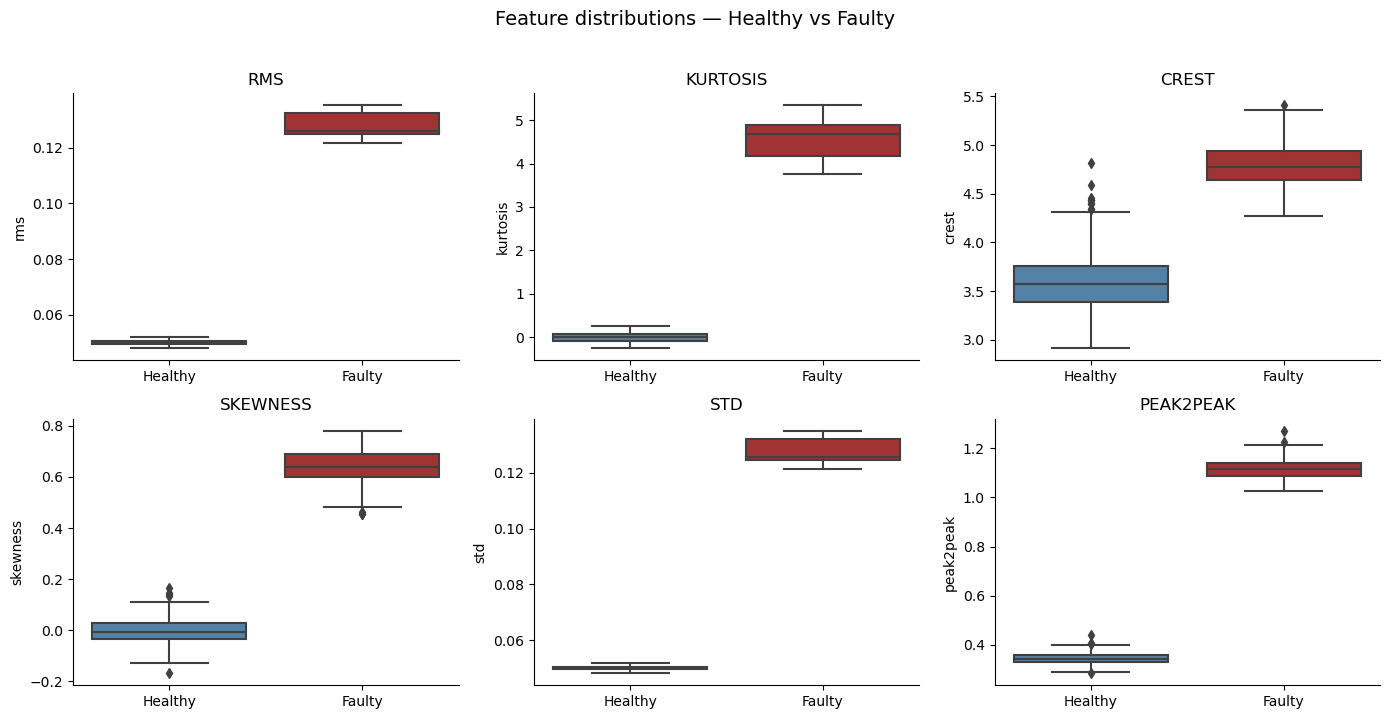

In [7]:
# Side-by-side boxplots for each feature
features_to_plot = ["rms", "kurtosis", "crest", "skewness", "std", "peak2peak"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, feat in zip(axes.flat, features_to_plot):
    sns.boxplot(data=all_feats, x="label", y=feat, ax=ax,
                palette={"Healthy": "steelblue", "Faulty": "firebrick"})
    ax.set_title(feat.upper())
    ax.set_xlabel("")

plt.suptitle("Feature distributions — Healthy vs Faulty", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### 🤔 Discussion (2 min)1. Which feature shows the **largest separation** between healthy and faulty?2. Which feature is **least useful** — i.e., the boxes overlap heavily?3. **Kurtosis insight:** A Gaussian noise signal has kurtosis ≈ 3. Anything above ~5 is impulsive. What does the faulty signal's kurtosis tell you about the *type* of defect?4. In a deployment scenario, if you could only afford to compute **one** feature on the edge device (limited compute), which would you pick — and why?

---## Part 3 — Anomaly Detection with Isolation Forest### Why Isolation Forest?| Model | Strengths | Why we picked it for this exercise ||---|---|---|| Statistical thresholds | Fast, no training | Misses contextual anomalies || **Isolation Forest** | Fast at scale, no labels needed, interpretable | ✅ **Our baseline** || One-Class SVM | Principled support estimation | Slower; γ/ν sensitive || LSTM Autoencoder | Captures temporal patterns | Needs GPU + large data |**Reference:** Liu, F.T., Ting, K.M., Zhou, Z.-H. (2008). "Isolation Forest." *Proc. 8th IEEE International Conference on Data Mining* (ICDM), pp. 413–422.### The key insightIsolation Forest trains **only on healthy data**. The model learns "what normal looks like". Anomalies are then defined as points the model finds *easy to isolate* — they sit outside the dense normal region.This is exactly the IRMS context: you have plenty of healthy operational data, but very few labelled fault examples.

In [8]:
# ──────────────────────────────────────────────────────────────────────
# Train Isolation Forest on HEALTHY DATA ONLY (unsupervised setup)
# ──────────────────────────────────────────────────────────────────────

feature_cols = ["rms", "kurtosis", "crest", "skewness", "std", "peak2peak"]

X_healthy = feats_healthy[feature_cols].values
X_faulty  = feats_faulty[feature_cols].values

# Standardise based on healthy statistics only
scaler = StandardScaler().fit(X_healthy)
X_healthy_scaled = scaler.transform(X_healthy)
X_faulty_scaled  = scaler.transform(X_faulty)

# Train Isolation Forest on healthy windows only
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # expect ~5% of "training" data to be borderline
    random_state=42,
)
iso.fit(X_healthy_scaled)

print("Isolation Forest trained on", len(X_healthy_scaled), "healthy windows.")

Isolation Forest trained on 234 healthy windows.


### Score every window — lower score = more anomalous

In [9]:
# Anomaly scores (lower = more anomalous)
score_healthy = iso.score_samples(X_healthy_scaled)
score_faulty  = iso.score_samples(X_faulty_scaled)

print(f"Mean healthy score: {score_healthy.mean():+.4f}  (should be near 0 or positive)")
print(f"Mean faulty score:  {score_faulty.mean():+.4f}  (should be more negative)")
print(f"Separation:         {score_healthy.mean() - score_faulty.mean():+.4f}")

Mean healthy score: -0.4469  (should be near 0 or positive)
Mean faulty score:  -0.7493  (should be more negative)
Separation:         +0.3024


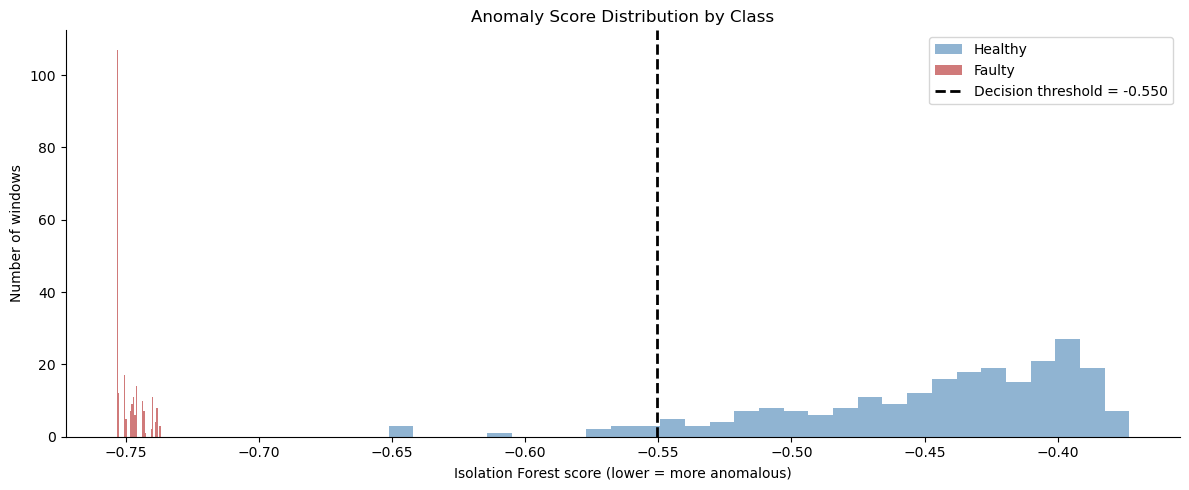

In [10]:
# Visualise score distributions
plt.figure(figsize=(12, 5))
plt.hist(score_healthy, bins=30, alpha=0.6, label="Healthy", color="steelblue")
plt.hist(score_faulty,  bins=30, alpha=0.6, label="Faulty",  color="firebrick")
plt.axvline(iso.offset_, color="black", linestyle="--", lw=2,
            label=f"Decision threshold = {iso.offset_:.3f}")
plt.xlabel("Isolation Forest score (lower = more anomalous)")
plt.ylabel("Number of windows")
plt.title("Anomaly Score Distribution by Class")
plt.legend()
plt.tight_layout()
plt.show()

### Classification report — how good is our detector?

In [11]:
# Build a binary ground truth: 0 = Healthy, 1 = Faulty
y_true = np.concatenate([
    np.zeros(len(X_healthy_scaled)),
    np.ones(len(X_faulty_scaled))
])

# Predict: -1 = anomaly (faulty), +1 = inlier (healthy)
y_pred = np.concatenate([
    (iso.predict(X_healthy_scaled) == -1).astype(int),
    (iso.predict(X_faulty_scaled)  == -1).astype(int)
])

print("Confusion matrix")
print("              Predicted Healthy  Predicted Faulty")
cm = confusion_matrix(y_true, y_pred)
print(f"True Healthy:        {cm[0,0]:>6}            {cm[0,1]:>6}")
print(f"True Faulty:         {cm[1,0]:>6}            {cm[1,1]:>6}")
print()
print("Classification report")
print(classification_report(y_true, y_pred,
                            target_names=["Healthy", "Faulty"], digits=3))

Confusion matrix
              Predicted Healthy  Predicted Faulty
True Healthy:           222                12
True Faulty:              0               234

Classification report
              precision    recall  f1-score   support

     Healthy      1.000     0.949     0.974       234
      Faulty      0.951     1.000     0.975       234

    accuracy                          0.974       468
   macro avg      0.976     0.974     0.974       468
weighted avg      0.976     0.974     0.974       468



#### 🤔 Discussion — the BUSINESS interpretation (5 min, in pairs)1. **Precision vs Recall — which matters more in safety?**   - High precision = when we cry wolf, there really is a wolf (few false alarms).   - High recall = we catch every wolf (few missed faults).   - Which is more important for an IRMS officer deciding whether to halt a Rajdhani at 3 AM? Why?2. **The 'contamination' parameter** is set to 0.05. Change it to 0.15 and re-run. What happens to:   - The decision threshold?   - Precision on the faulty class?   - Recall on the faulty class?   - The number of healthy windows flagged as "anomalous"?3. **Operational cost framing:** Suppose one false alarm costs ₹50,000 (delay + investigation) and one missed fault costs ₹5,00,00,000 (derailment). Roughly, what FP-rate are you willing to accept to achieve 99% recall on faults? *Hint: cost-weighted threshold tuning is a real production concern.*

---## Part 4 — From Scores to a Decision: Anomaly TimelineThe score distribution tells us the model works. But a controller in a section office needs a **time-series view** — when did the anomaly start, and how confident are we?

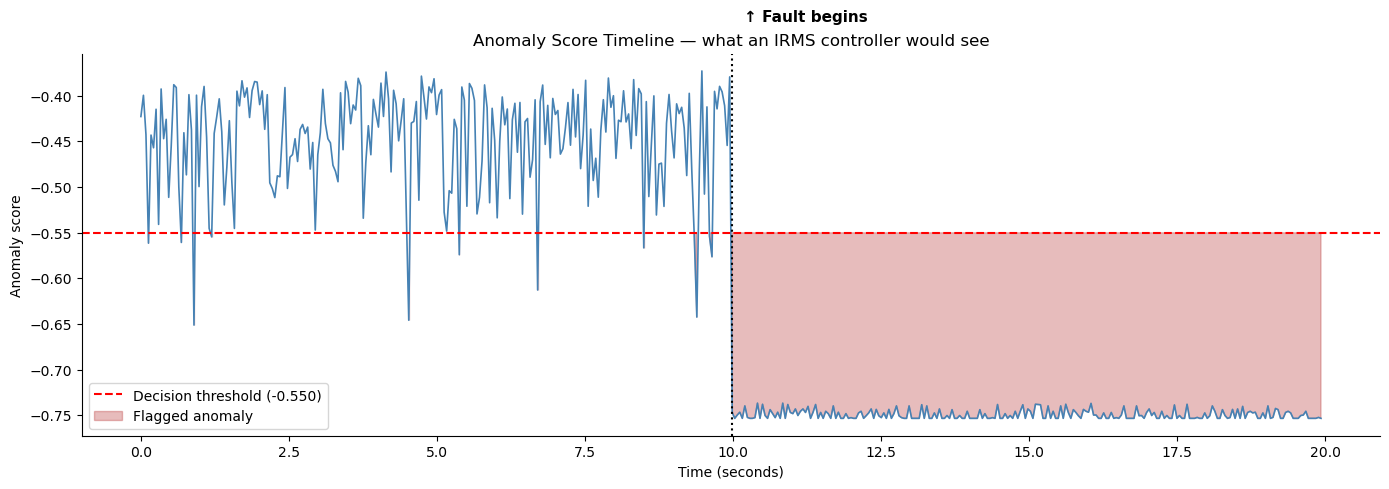

In [12]:
# Build a continuous timeline: pretend we got healthy data first, then faulty
all_scores = np.concatenate([score_healthy, score_faulty])
window_time_s = np.arange(len(all_scores)) * (WINDOW_SIZE / FS)

# When does each region begin?
healthy_end_s = len(score_healthy) * (WINDOW_SIZE / FS)

plt.figure(figsize=(14, 5))
plt.plot(window_time_s, all_scores, color="steelblue", lw=1.2)
plt.axhline(iso.offset_, color="red", linestyle="--", label=f"Decision threshold ({iso.offset_:.3f})")
plt.fill_between(window_time_s, all_scores, iso.offset_,
                 where=(all_scores < iso.offset_),
                 color="firebrick", alpha=0.3, label="Flagged anomaly")
plt.axvline(healthy_end_s, color="black", linestyle=":", lw=1.5)
plt.text(healthy_end_s + 0.2, plt.ylim()[1] * 0.9, "↑ Fault begins",
         fontsize=11, fontweight="bold")
plt.xlabel("Time (seconds)")
plt.ylabel("Anomaly score")
plt.title("Anomaly Score Timeline — what an IRMS controller would see")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

**👁 What to look for:**- Before the dotted line (healthy region): the score line hovers near or above the threshold.- After the dotted line (faulty region): the score drops sharply, and the red fill shows every flagged window.- The transition is **abrupt** — that's the signature of a real fault, not noise.#### 🤔 Discussion1. In a real deployment, what's the **minimum number of consecutive flagged windows** before the system should alert the controller? Why not alert on a single flagged window?2. What if the fault grows gradually (e.g., a slowly developing wheel flat)? How would you adapt the system?

---## Part 5 — Stretch Challenge: Compare with One-Class SVMIn Part 3 we used Isolation Forest. The slide deck listed **One-Class SVM** (Schölkopf et al. 2001) as an alternative. Let's compare them on the same data — same features, same evaluation.

In [13]:
# One-Class SVM — trained on healthy data only, just like IsolationForest
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.05,            # roughly the expected fraction of outliers
)
ocsvm.fit(X_healthy_scaled)

# Predict and compute the same confusion matrix
y_pred_svm = np.concatenate([
    (ocsvm.predict(X_healthy_scaled) == -1).astype(int),
    (ocsvm.predict(X_faulty_scaled)  == -1).astype(int)
])

print("ONE-CLASS SVM")
print(classification_report(y_true, y_pred_svm,
                            target_names=["Healthy", "Faulty"], digits=3))

print("\nISOLATION FOREST (recap)")
print(classification_report(y_true, y_pred,
                            target_names=["Healthy", "Faulty"], digits=3))

ONE-CLASS SVM
              precision    recall  f1-score   support

     Healthy      1.000     0.919     0.958       234
      Faulty      0.925     1.000     0.961       234

    accuracy                          0.959       468
   macro avg      0.962     0.959     0.959       468
weighted avg      0.962     0.959     0.959       468


ISOLATION FOREST (recap)
              precision    recall  f1-score   support

     Healthy      1.000     0.949     0.974       234
      Faulty      0.951     1.000     0.975       234

    accuracy                          0.974       468
   macro avg      0.976     0.974     0.974       468
weighted avg      0.976     0.974     0.974       468



#### 🤔 Discussion — which would YOU deploy?| Criterion | Isolation Forest | One-Class SVM ||---|---|---|| Training time | Fast | Slower (kernel matrix scales O(n²)) || Inference time | Fast | Fast || Interpretability | Score per tree path | Distance to support vectors || Sensitivity to hyper-parameters | Low (contamination) | High (nu, gamma) || Scales to large data | ✅ | ❌ above ~50k samples |In a production rail deployment with **millions** of windows per day across the fleet, Isolation Forest is usually the right starting point. One-Class SVM becomes attractive when your feature space is small but highly non-linear.

---## Part 6 — Working with Real CWRU DataThe synthetic generator above lets the notebook run anywhere. To swap in the real CWRU dataset:```python# 1. Download from https://engineering.case.edu/bearingdatacenter#    e.g., 48k_Drive_End_OR007@6_0_130.mat (outer race fault, 0.007″, 0 HP load)# 2. Load with scipy.io.loadmat:from scipy.io import loadmatdata = loadmat('48k_Drive_End_OR007@6_0_130.mat')signal_faulty = data['X130_DE_time'].ravel()  # drive-end accelerometer# 3. For a healthy reference, use a "Normal_Baseline" file:data_h = loadmat('48k_Normal_0HP.mat')signal_healthy = data_h['X097_DE_time'].ravel()# Everything else in this notebook works unchanged.```### What the real data adds- **Multiple fault severities** (0.007″, 0.014″, 0.021″, 0.028″ defect diameters) — lets you build a *severity classifier* on top of the anomaly detector.- **Multiple loads** (0, 1, 2, 3 HP) — exposes the non-stationarity problem we discussed in Part 1.- **Multiple fault locations** (inner race, outer race @ 3/6/12 o'clock, ball) — lets you build a *fault-type classifier*.### Production pipeline (from the slide deck)The Section 2 closing slide showed the full pipeline:```Sensor (onboard)  →  Edge device (FFT, windowing)  →  4G/5G backhaul       ↓Risk scoring engine (this notebook's model)       ↓Dashboard (IRMS control room)       ↓Human decision (halt / restrict / flag / dismiss)```The model you just built is **one of those boxes**. The other boxes — sensor calibration, backhaul reliability, dashboard UX, decision governance — are equally important. We covered governance in Section 3.

---## Wrap-Up — Key Takeaways1. **Vibration data is rich** — but raw waveforms are too high-dimensional. **Windowing + statistical features** (RMS, Kurtosis, Crest) compress signal to ML-ready vectors while preserving fault signatures.2. **Kurtosis catches what RMS misses.** Impulsive faults (wheel flats, outer-race defects) show up as kurtosis > 5 even when RMS is only marginally elevated.3. **Train on healthy data only.** This is the right framing when fault labels are scarce — which is *always* the case in safety-critical operations.4. **Isolation Forest is the right baseline** for rail PdM: fast, scalable, robust to hyper-parameter choice. Move to One-Class SVM or LSTM Autoencoders only when you have a specific reason.5. **Precision/Recall are business choices.** A 99% recall, 80% precision detector might be perfect for one rail division and unacceptable for another. The threshold lives in the operational policy, not the model.6. **Models are tools, not oracles.** Every anomaly score must terminate at a human decision — the IRMS officer with field context, accountability, and judgement.### Where to go next- Try **multivariate** features: tsfresh (Christ et al. 2018) produces ~794 features automatically.- Add **frequency-domain** features: FFT band energy at expected fault frequencies.- Build a **drift monitor**: a model trained 6 months ago will degrade. Track precision on a labelled validation slice every week.- Read the **Model Card** (Mitchell et al. 2019) you'd publish for this model. What fairness, robustness, and intended-use claims would it make?---### References1. Liu, F.T., Ting, K.M., Zhou, Z.-H. (2008). "Isolation Forest." *Proc. 8th IEEE ICDM*, pp. 413–422.2. Schölkopf, B., Platt, J.C., Shawe-Taylor, J., Smola, A.J., Williamson, R.C. (2001). "Estimating the Support of a High-Dimensional Distribution." *Neural Computation* 13(7): 1443–1471.3. Christ, M., Braun, N., Neuffer, J., Kempa-Liehr, A.W. (2018). "tsfresh — Time Series Feature Extraction." *Neurocomputing* 307: 72–77.4. ISO 20816-1:2016. *Mechanical vibration — Measurement and evaluation of machine vibration*.5. CWRU Bearing Data Center. Case School of Engineering. https://engineering.case.edu/bearingdatacenter6. Pedregosa, F. et al. (2011). "Scikit-learn: Machine Learning in Python." *JMLR* 12: 2825–2830.---*End of notebook. In the next session we'll move from rolling-stock health to **network-level delay prediction** — Predictive Transportation Analytics.*